# Laboratorio Semana 3: LSTM desde cero con PyTorch

**Curso:** Deep Learning  
**Valor:** 4% de la nota del curso  
**Entrega:** Notebook ejecutado (.ipynb) con todas las celdas con salida visible

---

## Contexto

Esta semana usted va a implementar un LSTM completo desde cero usando tensores de PyTorch: forward pass, backward pass manual y actualizacion de pesos. La tarea es clasificacion binaria sobre una secuencia sintetica: determinar si una secuencia de pares de numeros tiene tendencia creciente (etiqueta 1) o decreciente (etiqueta 0).

La arquitectura es la siguiente:

```
Secuencia x_1,...,x_T  ->  LSTM (T pasos)  ->  h_T  ->  Dense + sigmoid  ->  y_hat  ->  BCE
```

Es una arquitectura **many-to-one**: el LSTM lee toda la secuencia y solo la salida del ultimo paso $h_T$ se usa para clasificar.

## Reglas

- Use **unicamente PyTorch** para operaciones tensoriales. No use `nn.LSTM`, `nn.RNNCell`, `nn.Linear` ni ninguna capa de alto nivel.
- El backward pass debe ser **manual**: calcule cada gradiente a mano aplicando la regla de la cadena. No use `loss.backward()`.
- Las celdas marcadas con `# SU CODIGO AQUI` son las que debe completar.
- **No modifique las celdas de verificacion ni los pesos iniciales.**
- La celda final calcula su nota automatica sobre los **53 puntos** de la seccion de codigo.

In [1]:
import torch
import hashlib
import numpy as np
import matplotlib.pyplot as plt

def _hash_tensor(t, decimals=5):
    """Huella criptografica reproducible de un tensor PyTorch."""
    arr = np.round(t.detach().numpy().astype(np.float64), decimals)
    return hashlib.sha256(arr.tobytes()).hexdigest()

_resultados = {}
print("Librerias cargadas.")
print(f"PyTorch version: {torch.__version__}")

Librerias cargadas.
PyTorch version: 2.13.0+cu130


---
## Bloque 0: Datos y pesos iniciales (dado, no modificar)

La secuencia de entrada tiene $T=5$ pasos, cada uno un vector de dimension $n=2$.  
La dimension del hidden state es $d=4$.  
La etiqueta es $y=1$ (secuencia creciente).  

**No modifique los pesos iniciales**: el autograder depende de estos valores exactos.

In [2]:
# Datos
x_seq = torch.tensor([
    [0.1, 0.2],
    [0.3, 0.4],
    [0.5, 0.6],
    [0.7, 0.8],
    [0.9, 1.0],
], dtype=torch.float32)   # forma: (T=5, n=2)

label = torch.tensor([1.0])   # secuencia creciente

# Dimensiones
T = 5    # largo de la secuencia
n = 2    # dimension de entrada
d = 4    # dimension del hidden state

# Pesos iniciales fijos (torch.manual_seed(0))
torch.manual_seed(0)
W_f = torch.randn(d, d+n) * 0.1   # forget gate     (4, 6)
b_f = torch.zeros(d)
W_i = torch.randn(d, d+n) * 0.1   # input gate      (4, 6)
b_i = torch.zeros(d)
W_c = torch.randn(d, d+n) * 0.1   # candidato       (4, 6)
b_c = torch.zeros(d)
W_o = torch.randn(d, d+n) * 0.1   # output gate     (4, 6)
b_o = torch.zeros(d)
W_dense = torch.randn(1, d) * 0.1  # capa densa      (1, 4)
b_dense = torch.zeros(1)

alpha = 0.01   # tasa de aprendizaje
eps   = 1e-8   # estabilidad numerica en logaritmos

print(f"x_seq forma: {x_seq.shape}")
print(f"W_f forma:   {W_f.shape}  (d x d+n = {d} x {d+n})")
print(f"W_dense forma: {W_dense.shape}")

x_seq forma: torch.Size([5, 2])
W_f forma:   torch.Size([4, 6])  (d x d+n = 4 x 6)
W_dense forma: torch.Size([1, 4])


---
## FORWARD PASS

---

## Bloque 1: Las cinco ecuaciones de la celda LSTM

Implemente la celda LSTM para **un solo paso de tiempo** $t$.

Las cinco ecuaciones son:

$$f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$$
$$i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)$$
$$\tilde{c}_t = \tanh(W_c \cdot [h_{t-1}, x_t] + b_c)$$
$$c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t$$
$$o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o), \quad h_t = o_t \odot \tanh(c_t)$$

Donde $[h_{t-1}, x_t]$ es la concatenacion de ambos vectores y $\odot$ es el producto elemento a elemento.

**Nota:** use `torch.cat`, `torch.sigmoid`, `torch.tanh` y el operador `@` para el producto matricial.

In [3]:
def lstm_cell(h_prev, c_prev, x_t, W_f, b_f, W_i, b_i, W_c, b_c, W_o, b_o):
    """
    Un paso de tiempo de la celda LSTM.

    Parametros
    ----------
    h_prev : tensor (d,)  - hidden state del paso anterior
    c_prev : tensor (d,)  - cell state del paso anterior
    x_t    : tensor (n,)  - entrada en el paso actual
    W_f, b_f, W_i, b_i, W_c, b_c, W_o, b_o : pesos de cada compuerta

    Retorna
    -------
    h_t      : tensor (d,) - nuevo hidden state
    c_t      : tensor (d,) - nuevo cell state
    cache    : dict con todos los intermedios necesarios para el backward
    """
    # Paso 1: concatenar h_prev y x_t
    concat = torch.cat([h_prev, x_t])

    # Paso 2: forget gate
    f_t = torch.sigmoid(W_f @ concat + b_f)

    # Paso 3: input gate
    i_t = torch.sigmoid(W_i @ concat + b_i)

    # Paso 4: candidato
    c_tilde = torch.tanh(W_c @ concat + b_c)

    # Paso 5: actualizacion del cell state
    c_t = f_t * c_prev + i_t * c_tilde

    # Paso 6: output gate y nuevo hidden state
    o_t = torch.sigmoid(W_o @ concat + b_o)
    h_t = o_t * torch.tanh(c_t)

    cache = {
        'concat': concat, 'h_prev': h_prev, 'c_prev': c_prev,
        'f_t': f_t, 'i_t': i_t, 'c_tilde': c_tilde,
        'c_t': c_t, 'o_t': o_t, 'h_t': h_t,
    }

    return h_t, c_t, cache


# Prueba rapida con el primer paso de tiempo
h0 = torch.zeros(d)
c0 = torch.zeros(d)
h1, c1, cache1 = lstm_cell(h0, c0, x_seq[0], W_f, b_f, W_i, b_i, W_c, b_c, W_o, b_o)
print(f"h1 forma: {h1.shape if h1 is not None else 'None'}")
print(f"c1 forma: {c1.shape if c1 is not None else 'None'}")
print(f"f_t valores (deben estar en (0,1)): {cache1['f_t']}")

h1 forma: torch.Size([4])
c1 forma: torch.Size([4])
f_t valores (deben estar en (0,1)): tensor([0.5056, 0.5049, 0.5086, 0.4863])


---
## Bloque 2: Forward pass sobre la secuencia completa

Aplique `lstm_cell` en un loop sobre los $T=5$ pasos de tiempo.  
Inicialice $h_0$ y $c_0$ como vectores de ceros.  
Guarde el cache de cada paso en una lista `all_caches` para el backward.  
Al final, `h_T` es el hidden state del ultimo paso.

In [4]:
# Inicializacion
h = torch.zeros(d)
c = torch.zeros(d)
all_caches = []

# Loop sobre los T pasos de tiempo
for t in range(T):
    h, c, cache = lstm_cell(h, c, x_seq[t], W_f, b_f, W_i, b_i, W_c, b_c, W_o, b_o)
    all_caches.append(cache)

h_T = h   # hidden state del ultimo paso

print(f"h_T forma: {h_T.shape}")
print(f"h_T valores: {h_T}")
print(f"Numero de caches guardados: {len(all_caches)} (esperado: {T})")

h_T forma: torch.Size([4])
h_T valores: tensor([ 0.0139,  0.0320, -0.0048, -0.0596])
Numero de caches guardados: 5 (esperado: 5)


In [5]:
# VERIFICACION BLOQUE 2
_H = '53458c09a700bb2a647768325d5349ea983365ca96c4053b3dcc9927449de45c'
try:
    assert h_T is not None and h_T.shape == (d,), \
        f"h_T debe ser tensor de forma ({d},), obtenida {getattr(h_T,'shape',None)}"
    assert len(all_caches) == T, \
        f"all_caches debe tener {T} entradas, tiene {len(all_caches)}"
    assert _hash_tensor(h_T) == _H, "h_T incorrecto. Revise lstm_cell o el loop."
    _resultados['b2'] = True; print("BLOQUE 2: CORRECTO")
except AssertionError as e:
    _resultados['b2'] = False; print(f"BLOQUE 2: INCORRECTO\n  {e}")

BLOQUE 2: CORRECTO


---
## Bloque 3: Capa densa + sigmoid

Aplique la capa de clasificacion sobre $h_T$:

$$z = W_{dense} \cdot h_T + b_{dense}$$
$$\hat{y} = \sigma(z)$$

$W_{dense}$ tiene forma $(1, d)$ y $b_{dense}$ forma $(1,)$.  
El resultado $\hat{y}$ debe ser un escalar Python (`float`), no un tensor.

In [6]:
z_dense = W_dense @ h_T + b_dense   # producto matricial W_dense @ h_T + b_dense
y_hat   = torch.sigmoid(z_dense[0]).item()   # sigmoid de z_dense[0], convertido a float

print(f"z_dense: {z_dense}")
print(f"y_hat:   {y_hat}")

z_dense: tensor([0.0010])
y_hat:   0.5002414584159851


In [7]:
# VERIFICACION BLOQUE 3
_H = 'f1ed911992193e704bba77f6f1d1b67d4807e9197f767ced0ae37a0556cea904'
try:
    assert y_hat is not None, "y_hat no definido."
    assert isinstance(y_hat, float), \
        f"y_hat debe ser float, obtenido {type(y_hat)}"
    assert _hash_tensor(torch.tensor([y_hat])) == _H, \
        "y_hat incorrecto. Revise la capa densa o la sigmoid."
    _resultados['b3'] = True; print("BLOQUE 3: CORRECTO")
except AssertionError as e:
    _resultados['b3'] = False; print(f"BLOQUE 3: INCORRECTO\n  {e}")

BLOQUE 3: CORRECTO


---
## Bloque 4: Perdida BCE

Calcule la perdida de entropia cruzada binaria:

$$L = -\left[y \log(\hat{y} + \varepsilon) + (1-y)\log(1 - \hat{y} + \varepsilon)\right]$$

Use `eps = 1e-8` para estabilidad numerica. El resultado `loss` debe ser un escalar Python (`float`).

In [8]:
# SU CODIGO AQUI
y = label.item()
loss = -(y * np.log(y_hat + eps) + (1 - y) * np.log(1 - y_hat + eps))
loss = float(loss)

print(f"loss: {loss}")

loss: 0.6926643603044357


In [9]:
# VERIFICACION BLOQUE 4
try:
    assert loss is not None, "loss no definido."
    assert abs(loss - 0.692664) < 1e-4, \
        f"loss incorrecto: {loss:.6f}, esperado ~0.692664"
    _resultados['b4'] = True; print("BLOQUE 4: CORRECTO")
except AssertionError as e:
    _resultados['b4'] = False; print(f"BLOQUE 4: INCORRECTO\n  {e}")

BLOQUE 4: CORRECTO


---
## BACKWARD PASS

El backward recorre los pasos de tiempo en orden inverso, propagando el gradiente desde la perdida hasta los pesos de cada compuerta.

---

## Bloque 5: Gradientes de la capa densa y punto de entrada del backward

La simplificacion BCE + sigmoid da directamente:

$$\frac{\partial L}{\partial z} = \hat{y} - y$$

A partir de eso calcule:
- $\frac{\partial L}{\partial W_{dense}}$: forma $(1, d)$
- $\frac{\partial L}{\partial b_{dense}}$: forma $(1,)$
- $\frac{\partial L}{\partial h_T}$: forma $(d,)$ - gradiente que inicia el backward del LSTM

In [10]:
# SU CODIGO AQUI
dL_dz_dense  = y_hat - label.item() # escalar: y_hat - y
dL_dW_dense  = dL_dz_dense * h_T.unsqueeze(0) # forma (1, d)
dL_db_dense  = torch.tensor([dL_dz_dense]) # forma (1,)
dL_dh_next   = dL_dz_dense * W_dense.squeeze(0) # forma (d,): gradiente inicial hacia el LSTM

print(f"dL_dz_dense: {dL_dz_dense}")
print(f"dL_dW_dense forma: {dL_dW_dense.shape if dL_dW_dense is not None else None}")
print(f"dL_dh_next forma:  {dL_dh_next.shape  if dL_dh_next  is not None else None}")

dL_dz_dense: -0.4997585415840149
dL_dW_dense forma: torch.Size([1, 4])
dL_dh_next forma:  torch.Size([4])


---
## Bloque 6: Backward a traves del LSTM (BPTT)

Recorra los pasos de tiempo en orden inverso. En cada paso $t$, dado el gradiente entrante `dL_dh_next` y `dL_dc_next`, calcule:

1. $\frac{\partial L}{\partial o_t} = \frac{\partial L}{\partial h_t} \odot \tanh(c_t)$
2. $\frac{\partial L}{\partial c_t} \mathrel{+}= \frac{\partial L}{\partial h_t} \odot o_t \odot (1 - \tanh^2(c_t))$
3. $\frac{\partial L}{\partial f_t} = \frac{\partial L}{\partial c_t} \odot c_{t-1}$
4. $\frac{\partial L}{\partial i_t} = \frac{\partial L}{\partial c_t} \odot \tilde{c}_t$
5. $\frac{\partial L}{\partial \tilde{c}_t} = \frac{\partial L}{\partial c_t} \odot i_t$
6. Gradientes a traves de las activaciones (sigmoide y tanh)
7. Acumular en las matrices de pesos con `+=`
8. Propagar `dL_dh_next` y `dL_dc_next` al paso anterior

**Recuerde:** el operador `+=` en el paso 2 y en la acumulacion de pesos es critico: el gradiente se acumula sobre todos los pasos de tiempo, no se sobreescribe.

In [11]:
# Inicializar gradientes acumulados de los pesos
dL_dW_f = torch.zeros_like(W_f)
dL_dW_i = torch.zeros_like(W_i)
dL_dW_c = torch.zeros_like(W_c)
dL_dW_o = torch.zeros_like(W_o)
dL_db_f = torch.zeros_like(b_f)
dL_db_i = torch.zeros_like(b_i)
dL_db_c = torch.zeros_like(b_c)
dL_db_o = torch.zeros_like(b_o)

# El gradiente en c_T al inicio del backward es cero
dL_dc_next = torch.zeros(d)

for t in reversed(range(T)):
    cc = all_caches[t]
    # Extraer valores guardados en el forward
    f_t     = cc['f_t']
    i_t     = cc['i_t']
    c_tilde = cc['c_tilde']
    c_t     = cc['c_t']
    o_t     = cc['o_t']
    c_prev  = cc['c_prev']
    concat  = cc['concat']

    # SU CODIGO AQUI
    # Paso 1: gradiente en o_t
    dL_do = dL_dh_next * torch.tanh(c_t)

    # Paso 2: gradiente en c_t (acumular con +=)
    dL_dc = dL_dc_next + dL_dh_next * o_t * (1 - torch.tanh(c_t)**2)

    # Paso 3, 4, 5: gradientes en f_t, i_t, c_tilde
    dL_df    = dL_dc * c_prev
    dL_di    = dL_dc * c_tilde
    dL_dctil = dL_dc * i_t

    # Paso 6: a traves de las activaciones
    # sigmoide prima: sigma(z)*(1-sigma(z))
    # tanh prima: 1 - tanh^2(z)
    dz_f = dL_df * f_t * (1 - f_t)
    dz_i = dL_di * i_t * (1 - i_t)
    dz_c = dL_dctil * (1 - c_tilde**2)
    dz_o = dL_do * o_t * (1 - o_t)

    # Paso 7: acumular en matrices de pesos (usar torch.outer)
    dL_dW_f += torch.outer(dz_f, concat)
    dL_dW_i += torch.outer(dz_i, concat)
    dL_dW_c += torch.outer(dz_c, concat)
    dL_dW_o += torch.outer(dz_o, concat)
    dL_db_f += dz_f
    dL_db_i += dz_i
    dL_db_c += dz_c
    dL_db_o += dz_o

    # Paso 8: propagar al paso anterior
    dL_dconcat = W_f.T@dz_f + W_i.T@dz_i + W_c.T@dz_c + W_o.T@dz_o
    dL_dh_next = dL_dconcat[:d]
    dL_dc_next = dL_dc * f_t

print(f"dL_dW_f forma: {dL_dW_f.shape}")
print(f"dL_dW_f (primeros valores): {dL_dW_f[0,:3]}")

dL_dW_f forma: torch.Size([4, 6])
dL_dW_f (primeros valores): tensor([-2.0177e-07, -4.9691e-07,  9.0586e-08])


In [12]:
# VERIFICACION BLOQUE 6
_HASHES_B6 = {
    'dL_dW_f': 'deb8eb9ddd2fb6d11ecc1d1ca52135c551c8f89778bbbefe26d41de74167e166',
    'dL_dW_i': 'cff9e6d62a716bc98aafce5d6c879db5a7c195db5dafeddb556b5e3a13ee5906',
    'dL_dW_c': '121e33734655d3cded031e295086f4cd26a3d66c62b89d4cf046b67131116cde',
    'dL_dW_o': 'fca73403669043e504e444f1a5a20568b21d682c056e6b75b791827ec2f912a8',
}
_ARRAYS_B6 = {
    'dL_dW_f': dL_dW_f, 'dL_dW_i': dL_dW_i,
    'dL_dW_c': dL_dW_c, 'dL_dW_o': dL_dW_o,
}
try:
    for name, arr in _ARRAYS_B6.items():
        assert arr is not None and arr.shape == (d, d+n), \
            f"{name} debe ser ({d},{d+n}), obtenida {getattr(arr,'shape',None)}"
        assert _hash_tensor(arr) == _HASHES_B6[name], \
            f"{name} incorrecto. Revise el backward del paso {name[-1].upper()}."
    _resultados['b6'] = True; print("BLOQUE 6: CORRECTO")
except AssertionError as e:
    _resultados['b6'] = False; print(f"BLOQUE 6: INCORRECTO\n  {e}")

BLOQUE 6: CORRECTO


---
## Bloque 7: Actualizacion de todos los parametros

Aplique una iteracion de gradiente descendente sobre todos los parametros:

$$\theta \leftarrow \theta - \alpha \cdot \frac{\partial L}{\partial \theta}$$

Actualice: `W_f`, `W_i`, `W_c`, `W_o`, `b_f`, `b_i`, `b_c`, `b_o`, `W_dense`, `b_dense`.  
Guarde los pesos actualizados en variables con sufijo `_new`.

In [13]:
# Actualizacion por descenso de gradiente: theta_new = theta - alpha * gradiente
W_f_new = W_f - alpha * dL_dW_f
W_i_new = W_i - alpha * dL_dW_i
W_c_new = W_c - alpha * dL_dW_c
W_o_new = W_o - alpha * dL_dW_o
b_f_new = b_f - alpha * dL_db_f
b_i_new = b_i - alpha * dL_db_i
b_c_new = b_c - alpha * dL_db_c
b_o_new = b_o - alpha * dL_db_o
W_dense_new = W_dense - alpha * dL_dW_dense
b_dense_new = b_dense - alpha * dL_db_dense

print(f"W_f_new forma:     {W_f_new.shape}")
print(f"W_dense_new forma: {W_dense_new.shape}")

W_f_new forma:     torch.Size([4, 6])
W_dense_new forma: torch.Size([1, 4])


In [14]:
# VERIFICACION BLOQUE 7
_HASHES_B7 = {
    'W_f_new':     '8c8afcb78c9fb2e6dec91cde852776cc02f8ebc5d3a4e840259bc7d3edb610ff',
    'W_i_new':     '055b6638846f02460d47688eea615cf0cab768a90b4af8640f396ce7652efb12',
    'W_dense_new': '24a5d73dcc15c337468cb18a1dc6034dec341d3c7032e6706f1126dc5f87c4be',
}
_ARRAYS_B7 = {
    'W_f_new': W_f_new, 'W_i_new': W_i_new, 'W_dense_new': W_dense_new
}
try:
    for name, arr in _ARRAYS_B7.items():
        assert arr is not None, f"{name} no definido."
        assert _hash_tensor(arr) == _HASHES_B7[name], \
            f"{name} incorrecto. Verifique la actualizacion de ese parametro."
    _resultados['b7'] = True; print("BLOQUE 7: CORRECTO")
except AssertionError as e:
    _resultados['b7'] = False; print(f"BLOQUE 7: INCORRECTO\n  {e}")

BLOQUE 7: CORRECTO


---
## Bloque 8: Verificacion de convergencia en 5 iteraciones

Implemente un loop de entrenamiento de 5 iteraciones usando sus funciones `lstm_cell` y el backward manual.  
En cada iteracion: forward pass completo, calculo de loss, backward completo, actualizacion de pesos.  
Guarde la loss de cada iteracion en la lista `losses`.  
Verifique que la loss decrece monotonamente en las 5 iteraciones.

In [15]:
# Reiniciar pesos a los valores iniciales
torch.manual_seed(0)
Wf=torch.randn(d,d+n)*0.1; bf=torch.zeros(d)
Wi=torch.randn(d,d+n)*0.1; bi=torch.zeros(d)
Wc=torch.randn(d,d+n)*0.1; bc=torch.zeros(d)
Wo=torch.randn(d,d+n)*0.1; bo=torch.zeros(d)
Wd=torch.randn(1,d)*0.1;   bd=torch.zeros(1)

losses = []

for it in range(5):
    # Forward pass completo y almacenamiento de los intermedios para BPTT
    h = torch.zeros(d)
    c = torch.zeros(d)
    caches = []
    for t in range(T):
        h, c, cache = lstm_cell(h, c, x_seq[t], Wf, bf, Wi, bi, Wc, bc, Wo, bo)
        caches.append(cache)

    # Capa densa, sigmoid y BCE
    y_pred = torch.sigmoid((Wd @ h + bd)[0]).item()
    current_loss = -(
        label.item() * np.log(y_pred + eps)
        + (1 - label.item()) * np.log(1 - y_pred + eps)
    )
    losses.append(float(current_loss))

    # Gradientes de la capa densa
    dz_dense = y_pred - label.item()
    grad_Wd = dz_dense * h.unsqueeze(0)
    grad_bd = torch.tensor([dz_dense])
    dh_next = dz_dense * Wd.squeeze(0)
    dc_next = torch.zeros(d)

    # Gradientes acumulados de las cuatro compuertas
    grad_Wf = torch.zeros_like(Wf); grad_bf = torch.zeros_like(bf)
    grad_Wi = torch.zeros_like(Wi); grad_bi = torch.zeros_like(bi)
    grad_Wc = torch.zeros_like(Wc); grad_bc = torch.zeros_like(bc)
    grad_Wo = torch.zeros_like(Wo); grad_bo = torch.zeros_like(bo)

    for t in reversed(range(T)):
        cc = caches[t]
        f_t, i_t = cc['f_t'], cc['i_t']
        c_tilde, c_t = cc['c_tilde'], cc['c_t']
        o_t, c_prev, concat = cc['o_t'], cc['c_prev'], cc['concat']

        do = dh_next * torch.tanh(c_t)
        dc = dc_next + dh_next * o_t * (1 - torch.tanh(c_t) ** 2)
        df = dc * c_prev
        di = dc * c_tilde
        dc_tilde = dc * i_t

        dz_f = df * f_t * (1 - f_t)
        dz_i = di * i_t * (1 - i_t)
        dz_c = dc_tilde * (1 - c_tilde ** 2)
        dz_o = do * o_t * (1 - o_t)

        grad_Wf += torch.outer(dz_f, concat); grad_bf += dz_f
        grad_Wi += torch.outer(dz_i, concat); grad_bi += dz_i
        grad_Wc += torch.outer(dz_c, concat); grad_bc += dz_c
        grad_Wo += torch.outer(dz_o, concat); grad_bo += dz_o

        dconcat = Wf.T @ dz_f + Wi.T @ dz_i + Wc.T @ dz_c + Wo.T @ dz_o
        dh_next = dconcat[:d]
        dc_next = dc * f_t

    # Actualizacion simultanea de todos los parametros
    Wf -= alpha * grad_Wf; bf -= alpha * grad_bf
    Wi -= alpha * grad_Wi; bi -= alpha * grad_bi
    Wc -= alpha * grad_Wc; bc -= alpha * grad_bc
    Wo -= alpha * grad_Wo; bo -= alpha * grad_bo
    Wd -= alpha * grad_Wd; bd -= alpha * grad_bd

print("Losses por iteracion:")
for i, l in enumerate(losses):
    print(f"  Iteracion {i+1}: {l:.6f}")

Losses por iteracion:
  Iteracion 1: 0.692664
  Iteracion 2: 0.690131
  Iteracion 3: 0.687610
  Iteracion 4: 0.685102
  Iteracion 5: 0.682606


In [16]:
# VERIFICACION BLOQUE 8
try:
    assert len(losses) == 5, \
        f"losses debe tener 5 valores, tiene {len(losses)}"
    assert all(losses[i] > losses[i+1] for i in range(4)), \
        f"La loss no decrece monotonamente: {[round(l,6) for l in losses]}"
    assert abs(losses[0] - 0.692664) < 1e-4, \
        f"Loss inicial incorrecta: {losses[0]:.6f}"
    _resultados['b8'] = True
    print("BLOQUE 8: CORRECTO")
    print(f"  Reduccion total: {losses[0]:.6f} -> {losses[-1]:.6f} "
          f"({(losses[0]-losses[-1])/losses[0]*100:.3f}%)")
except AssertionError as e:
    _resultados['b8'] = False; print(f"BLOQUE 8: INCORRECTO\n  {e}")

BLOQUE 8: CORRECTO
  Reduccion total: 0.692664 -> 0.682606 (1.452%)


---
## Bloque 9: Visualizacion de la convergencia (dado, ejecute y analice)

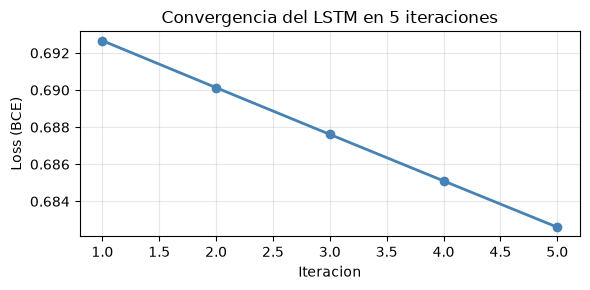

Grafica guardada como convergencia_lstm.png


In [17]:
if losses:
    plt.figure(figsize=(6,3))
    plt.plot(range(1, len(losses)+1), losses, 'o-', color='steelblue', linewidth=2)
    plt.xlabel('Iteracion'); plt.ylabel('Loss (BCE)')
    plt.title('Convergencia del LSTM en 5 iteraciones')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('convergencia_lstm.png', dpi=110, bbox_inches='tight')
    plt.show()
    print("Grafica guardada como convergencia_lstm.png")

---
## Bloque 10: Preguntas de analisis

Responda en las celdas Markdown habilitadas. Sus respuestas deben conectar los resultados numericos con los conceptos de clase. No es suficiente describir lo que ocurre: debe argumentar por que ocurre y que implicacion tiene.

---

### Pregunta 1 (35 pts de la seccion de analisis)

En el Bloque 6, el gradiente de $c_t$ se calcula con el operador `+=` en el paso 2:

```python
dL_dc = dL_dc_next + dL_dh * o_t * (1 - torch.tanh(c_t)**2)
```

a) Explique de donde viene cada uno de los dos terminos que se suman. ¿Que ruta del grafo de computo representa cada uno? Trace la ruta desde $L$ hasta $c_t$ para cada termino.

b) Si en su implementacion hubiera usado `=` en lugar de `+=`, ¿que informacion se perderia y como afectaria eso al entrenamiento? Razone en terminos del grafo de computo, no solo del codigo.

c) Compare esta acumulacion con lo que ocurria en el backward de la convolucion de la Semana 2, donde el gradiente del kernel tambien usaba `+=`. ¿Que tienen en comun los dos casos? ¿Que los hace diferentes?

**Su respuesta a la Pregunta 1:**

**a) Origen de los dos terminos**

El gradiente de (c_t) es la suma de dos contribuciones porque (c_t) tiene **dos rutas de salida** en el grafo de cómputo: una **local**, que pasa por (h_t = o_t \odot \tanh(c_t)), y otra **recurrente**, que viene desde (c_{t+1}) y transporta información de los pasos futuros mediante la forget gate. Por la regla de la cadena, ambas contribuciones deben sumarse.

**b) Que pasaria con `=` en lugar de `+=`**

Si se usara `=` en lugar de `+=`, se perdería el gradiente que llega desde los pasos futuros (`dL_dc_next`). Esto cortaría la propagación temporal del error, haciendo que el LSTM aprenda solo dependencias locales y perdiendo su capacidad para modelar relaciones de largo plazo.

**c) Comparacion con el backward de la convolucion (Semana 2)**

Igual que en la convolución, `+=` se utiliza porque un mismo valor participa en **múltiples rutas del grafo** y el gradiente total es la suma de todas sus contribuciones. La diferencia es que en la convolución la acumulación ocurre sobre posiciones espaciales independientes de un parámetro compartido, mientras que en el LSTM ocurre sobre la dimensión temporal, donde existe una dependencia secuencial entre los pasos del tiempo.


---
### Pregunta 2 (35 pts de la seccion de analisis)

Considere una variante del LSTM donde la forget gate se fija en cero: $f_t = \mathbf{0}$ para todo $t$, sin aprender.

a) ¿Que le ocurre al cell state $c_t$ en cada paso de tiempo si $f_t = \mathbf{0}$? Escriba la ecuacion simplificada de $c_t$ y describa que tipo de memoria tiene el modelo resultante.

b) ¿Que le ocurre a la ruta directa del gradiente a traves del cell state? Muestre matematicamente como cambia $\frac{\partial c_t}{\partial c_{t-1}}$ y que consecuencia tiene eso para el aprendizaje de dependencias de largo plazo.

c) En su implementacion del Bloque 8, la loss decrecio monotonamente. ¿Ese comportamiento seguiria ocurriendo con $f_t = \mathbf{0}$? ¿Dependeria del largo de la secuencia $T$? Justifique.

**Su respuesta a la Pregunta 2:**

a) Con $f_t = \mathbf{0}$ el termino $f_t \odot c_{t-1}$ desaparece y la ecuacion se reduce a $c_t = i_t \odot \tilde{c}_t$. El cell state deja de acarrear informacion de $c_{t-1}$ en cada paso se reescribe por completo en funcion unicamente de la entrada y el hidden state actuales. El modelo pierde la memoria de largo plazo y se comporta como una red que solo tiene memoria de un paso (equivalente, en terminos de informacion retenida, a una celda sin componente recurrente en $c$).

b) Como $c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t$ (que complicado es copiar el latex este jaja), se tiene $\frac{\partial c_t}{\partial c_{t-1}} = f_t$. Con $f_t = \mathbf{0}$ esa derivada es exactamente cero en todo paso de tiempo, por lo que la ruta directa del gradiente a traves del cell state (la "autopista" que en el LSTM normalmente evita el desvanecimiento) queda cortada en cada $t$. El gradiente que llega a $c_t$ no puede propagarse mas alla de un paso por esa via; solo podria llegar a pasos anteriores indirectamente a traves de $h_{t-1}$ y las compuertas, ruta que vuelve a pasar por productos de derivadas de sigmoides y tanh y por lo tanto vuelve a sufrir el mismo desvanecimiento que en una RNN simple. En consecuencia, el modelo pierde la capacidad de aprender dependencias de largo plazo, que es precisamente lo que la forget gate esta disenada para preservar.

c) Es probable que la loss siga decreciendo monotonamente en las primeras 5 iteraciones, y ese comportamiento no dependeria fuertemente de $T$ en ese horizonte tan corto. La razon es que, aun con $f_t=\mathbf{0}$, el gradiente que llega desde la capa densa sigue actualizando correctamente las compuertas del ultimo paso (a traves de $i_T$, $\tilde{c}_T$ y $o_T$, que dependen de $h_{T-1}$ y $x_T$), y ese ajuste local basta para reducir la BCE en pocas iteraciones. Lo que cambia con $T$ no es la convergencia inicial sino la calidad de lo que se aprende: para $T$ grande el modelo no podria explotar la tendencia de la secuencia completa, solo el patron de los ultimos pasos, por lo que aunque la loss siga bajando en el corto plazo, el modelo convergeria a una solucion que ignora la informacion temprana de la secuencia.

---
### Pregunta 3 (30 pts de la seccion de analisis)

Su implementacion del backward en el Bloque 6 acumula gradientes sobre los $T=5$ pasos de tiempo. Considere que la secuencia se extiende a $T=50$ pasos manteniendo el mismo patron creciente.

a) En la RNN basica, ¿como cambiaria el gradiente que llega a los pesos que procesaron el primer paso $t=1$ comparado con los que procesaron el ultimo paso $t=50$? Muestre el factor de escala usando la formula derivada en clase.

b) En el LSTM, ¿como afecta el aumento de $T$ a la ruta del gradiente a traves del cell state? ¿Que condicion sobre los valores de $f_t$ garantiza que el gradiente no se desvanezca en esa ruta?

c) En su implementacion actual del backward, el loop recorre $T$ pasos. Si $T$ aumenta de 5 a 50, ¿que cambia en el codigo y que permanece igual? ¿Hay algun riesgo numerico que deba considerar?

**Su respuesta a la Pregunta 3:**

**a)** En una RNN básica, el gradiente hacia un estado temprano contiene un producto de Jacobianos recurrentes. Si $h_t=\phi(W_hh_{t-1}+W_xx_t+b)$, entonces

$$
\frac{\partial L}{\partial h_1}
=
\frac{\partial L}{\partial h_{50}}
\prod_{k=2}^{50}
\left(W_h^{\mathsf T}\operatorname{diag}(\phi'(a_k))\right).
$$

Por tanto, su escala queda acotada aproximadamente por

$$
\left\|\frac{\partial L}{\partial h_1}\right\|
\le
\left\|\frac{\partial L}{\partial h_{50}}\right\|
\left(\|W_h\|\,\max_k\|\phi'(a_k)\|\right)^{49}.
$$

El gradiente asociado con $t=50$ atraviesa pocas transformaciones, mientras que el de $t=1$ acumula 49 factores. Si el factor efectivo es menor que uno, el gradiente se desvanece exponencialmente; si es mayor que uno, puede explotar.

**b)** En la ruta directa del cell state del LSTM se cumple $\partial c_t/\partial c_{t-1}=f_t$. Al extender la secuencia, el gradiente entre los extremos contiene

$$
\frac{\partial c_{50}}{\partial c_1}
=
\prod_{k=2}^{50} f_k
$$

(elemento a elemento). El LSTM evita el desvanecimiento por esta ruta cuando las forget gates de las dimensiones que guardan información permanecen cercanas a $1$, de modo que el producto también permanece cercano a $1$. No basta con que cada $f_t$ sea positivo: si están uniformemente por debajo de $1$, su producto puede tender a cero al crecer $T$.

**c)** El algoritmo no cambia: el forward sigue recorriendo `range(T)`, guarda un cache por paso y el backward recorre `reversed(range(T))`, acumulando los mismos gradientes. Solo cambian el número de iteraciones, la lista de caches y el costo temporal y de memoria, ambos lineales en $T$; además, `x_seq` debe contener los 50 pasos. Numéricamente, productos repetidos de Jacobianos o de forget gates pueden desvanecer el gradiente, mientras que Jacobianos con norma mayor que uno pueden hacerlo explotar. Conviene vigilar las normas de los gradientes y, si explotan, aplicar *gradient clipping*; también debe evitarse la saturación de sigmoid y tanh porque reduce sus derivadas.

---
## Bloque 11: Nota automatica sobre la seccion de codigo

In [18]:
# NOTA AUTOMATICA - no modificar
_PUNTOS = {
    'b2': ('Bloque 2:  Forward pass secuencia completa',    18),
    'b3': ('Bloque 3:  Capa densa + sigmoid',                8),
    'b4': ('Bloque 4:  Perdida BCE',                         7),
    'b6': ('Bloque 6:  Backward LSTM (BPTT)',               12),
    'b7': ('Bloque 7:  Actualizacion de pesos',              5),
    'b8': ('Bloque 8:  Convergencia en 5 iteraciones',       3),
}
_TOTAL = 53

print("=" * 60)
print("  NOTA AUTOMATICA - SECCION DE CODIGO")
print("=" * 60)
_obtenido = 0
for key, (nombre, pts_max) in _PUNTOS.items():
    ok  = _resultados.get(key, False)
    pts = pts_max if ok else 0
    _obtenido += pts
    estado = "CORRECTO" if ok else "PENDIENTE"
    print(f"  {estado:10s} | {nombre:40s} | {pts:2d}/{pts_max} pts")

print("-" * 60)
print(f"  Subtotal codigo:   {_obtenido}/{_TOTAL} puntos")
print()
print("  Pendiente de calificacion manual:")
print("    Bloque 10 - Preguntas de analisis : __/30 pts")
print("    Comentarios en el codigo          : __/17 pts")
print("-" * 60)
print("  TOTAL FINAL (sobre 100):             __/100 pts")
print("=" * 60)

if _obtenido == _TOTAL:
    print("\n  Todos los bloques de codigo son correctos.")
elif _obtenido == 0:
    print("\n  Ninguna implementacion verificada. Ejecute los bloques en orden.")
else:
    pendientes = [n for k,(n,_) in _PUNTOS.items() if not _resultados.get(k,False)]
    print("\n  Bloques pendientes:")
    for p in pendientes:
        print(f"    - {p}")

  NOTA AUTOMATICA - SECCION DE CODIGO
  CORRECTO   | Bloque 2:  Forward pass secuencia completa | 18/18 pts
  CORRECTO   | Bloque 3:  Capa densa + sigmoid          |  8/8 pts
  CORRECTO   | Bloque 4:  Perdida BCE                   |  7/7 pts
  CORRECTO   | Bloque 6:  Backward LSTM (BPTT)          | 12/12 pts
  CORRECTO   | Bloque 7:  Actualizacion de pesos        |  5/5 pts
  CORRECTO   | Bloque 8:  Convergencia en 5 iteraciones |  3/3 pts
------------------------------------------------------------
  Subtotal codigo:   53/53 puntos

  Pendiente de calificacion manual:
    Bloque 10 - Preguntas de analisis : __/30 pts
    Comentarios en el codigo          : __/17 pts
------------------------------------------------------------
  TOTAL FINAL (sobre 100):             __/100 pts

  Todos los bloques de codigo son correctos.
